# Signal to Noise Ratio for different AES leakage models : LSB, LS2B, MSB, HW and ID
In this notebook is explained how to compute SNR for a set of traces and it's use the SNR to predict the number of traces required for a successfull DPA attack.

For side channels the signal is the information exploitable for an attack and everything else is noise. Depending on the chosen leakage model, the same point (or time sample) may have different ratios of signal and noise as different attacks exploit different properties of the underlying operation. Of course, the more signal is present, the more easy an attack will be.

This notebook is an adaption of the notebook of ileana buhan from [here](https://github.com/ileanabuhan/LeakageAssessment/blob/main/SNR.ipynb)

### Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import serial.tools.list_ports as port_list
import sys

sys.path.append( '../../../ciphers/AES_python' )
sys.path.append( '../../../sca_python' )

# Set the S-Box to test
tested_sbox = "sbox_rijandael"
sbox_id = tested_sbox.replace("sbox_", "")

In [2]:
# If capure is set to True, the script will capture data from the PicoScope
capture = False
# If save_dataset is set to True, the script will save the captured data to a .dat file
save_dataset = True

In [3]:
sys.path.append('../../../sca_python/utils')
from dat_tracereader import dat_tracereader

# Configuration parameters
pt_len = 16  # size of the plaintext in bytes
ct_len = 16  # size of the ciphertext in bytes
key_len = 16  # size of the key in bytes
n_trc = 5000  # number of traces to capture or read from dataset
    
if not capture:
    try:
        reader = dat_tracereader()
        reader.open_ro("../../dataset/aes_"+sbox_id+".dat")
        trace, key, plaintext, ciphertext =  reader.read_traces(n_trc)
        num_samples = trace.shape[1]  # number of samples per trace
        reader.close()
    except Exception as e:
        print("Error loading dataset: ", e)
else: 
    # Allocate memory for traces and data
    num_samples = 1612
    trace = np.empty((n_trc, num_samples), dtype=np.float64)  
    plaintext = np.empty((n_trc, pt_len), dtype=np.uint8)  
    ciphertext = np.empty((n_trc, ct_len), dtype=np.uint8)  
    key = np.empty(key_len, dtype=np.uint8) 

## Optional online phase : AES power traces capture

### Picoscope and CW305 initialization and capture of power traces

In [ ]:
from tqdm.notebook import tnrange
import chipwhisperer as cw
from Crypto.Cipher import AES
from pico_api import PS5000aWrapper
from CW305_api import CW305Wrapper
from AES_golden import AES_golden_model
import time

if capture:
    # Set the bitstream file path based on the S-Box
    bitstream = r"../../../../hw/fpga/bitstream/aes/aes_single_round/cw305_top_"+sbox_id+"_lut.bit"

        # Load the bitstream on the CW305 board and initialize the PicoScope
    try:
        # Initialize picoscope
        ps = PS5000aWrapper()
        ps.get_unitInfo()
        ps.scope_setup()
        num_samples = ps.nSamples
        # Initialize CW305
        cw305 = CW305Wrapper(ps, bitstream)
    except ModuleNotFoundError as e:
        print(e)
    
    # Initialize key,text pair generator
    ktp = cw.ktp.Basic()
    key, plaintext[0] = ktp.next()

    # Initialize the AES software emulated cipher
    cipher = AES_golden_model()

    # Each element of the key is converted to a 2-digit hex string 
    formatted_key = ''.join(format(el, '02x') for el in key)
    print("Key: ", [ hex(subkey) for subkey in key])

    # Write the key to the CW305
    cw305.set_key(key)

    # Dummy capture call due to bug of using AC coupling
    cw305.capture_trace(plaintext[0])

    for i in tnrange(n_trc, desc='Capturing traces'):
        ciphertext[i], trace[i] = cw305.capture_trace(plaintext[i])
        # Sanity check with expected ciphertext
        formatted_pt = (format(el, '02x') for el in plaintext[i])
        text = [int(subbyte, 16) for subbyte in formatted_pt]
        assert (list(ciphertext[i]) == list(cipher.encrypt(formatted_key, text, tested_sbox))), "Incorrect encryption result!\nGot {}\nExp {}\n".format(list(ciphertext[i]), list(plaintext[i]))
        if (i < n_trc-1):
            _ , plaintext[i+1] = ktp.next() 

    # Disconnect CW305 and picoscope
    cw305.dis()
    ps.dis()

    # If save_dataset is set to True, the attack data are stored to a .dat file
    if (save_dataset):
        try:
            writer = dat_tracereader()
            key = np.array(key, dtype=np.uint8)
            writer.create(
                pathname="dataset/aes_"+sbox_id+".dat",
                trace_len=int(num_samples),
                sample_type='d',
                key_len=key_len,
                plaintext_len=pt_len,
                ciphertext_len=ct_len
            )
            writer.write_traces(trace, key, plaintext, ciphertext)
            print("Traces written:", writer.num_traces)
            writer.close()
        except Exception as e:
            print("Error saving dataset: ", e)

### Plotting power traces captured (40 samples overlapped)

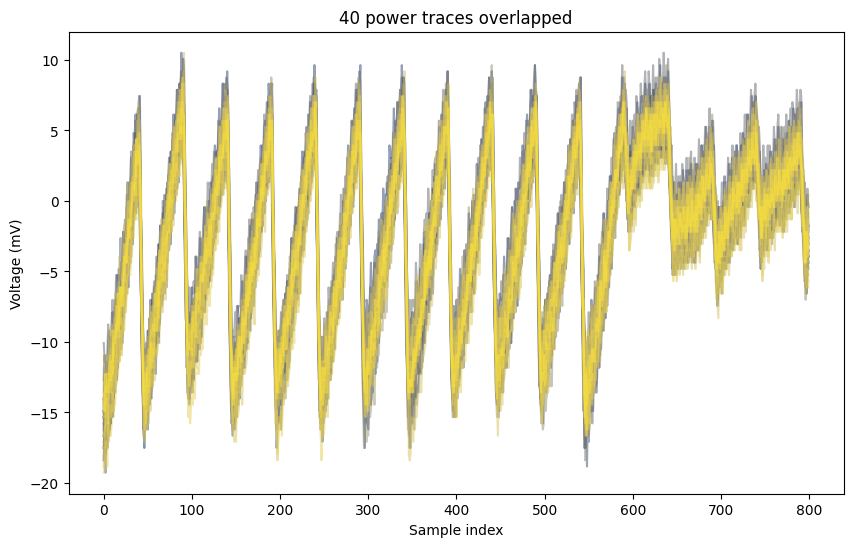

<Figure size 640x480 with 0 Axes>

In [5]:
import os
from analyzer.utils.sca_plots import sca_plot

sca_plt = sca_plot()
power_plt = sca_plt.power_traces_overlapped(traces=list(trace), finish=800)
power_plt.show()
# Ensure the Graphs directory exists
os.makedirs("Graphs", exist_ok=True)
power_plt.savefig("Graphs/power_traces_overlapped"+tested_sbox+".png")

## SNR AES

The attacked state is the ouput of round 9, hence interested in evaluating the SNR of this state for different leakage models.

Some definitions of variables to help us decypher the code:

- `TARGET_BYTE`, the attack is performed using divide-and-conquer approach, one byte at a time. This variable represents the key byte we are recovering. 
- `BYTE_COMBINATIONS`, is a constant which represents the number of hypothesis, `key_hypothesis`, we make for determining the correct value of `TARGET_BYTE`
-`prediction_matrix`, for each plaintext(=`number_of_traces`), and for each `key_hypothesis` compute the S-box out for `TARGET_BYTE`


<p align="center">
  <img src="media/AES-lastRound.png" alt="AES last round state">

Compute and compare the SNR for three leakage models:

a) Least Significant Bit (LSB), which looks only at 1 bit of our target byte;

b) Least Significant 2 Bits (LS2B), which looks at the last 2 bits in the target byte;

c) Hamming Weight (HW), which looks at the number of ones in the target byte.

The figure below illustrates the exploitable information for our three chosen leakage models and we see that what we consider signal (green) or noise (purple) is determined by the choice of leakage model. 

SNR is computed independently for each time sample in the trace.

<p align="center">
  <img src="media/Exploited_information_SNR.png" alt="Exploited information of SNR">
</p>

The trace set is split according to the values associated with our leakage model.
 For example:

- For the LSB leakage model, we create two groups, where LSB(k)=0 and LSB(k)=1

- For the LS2B leakage model, we create four groups, where LSB(k)=0, LSB(k)=1, LSB(k)=2 and LSB(k)=3.

- For the HD leakage model, we would split the trace set in 9 groups, where HD(k)=0, HD(k)=1, ..HD(k)=8


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
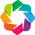

In [6]:
import chipwhisperer as cw
import chipwhisperer.analyzer as cwa
import holoviews as hv
hv.extension('bokeh')
import sys
import numpy as np
from tqdm.notebook import tqdm

sys.path.append('../../../sca_python/analyzer/attack/aes')

from analyzer.attack.aes.key_schedule import key_schedule_rounds
from sbox_modified_funcs import inv_sbox_lut

In [7]:
key_last_round = np.array(key_schedule_rounds(key, 0, 10, tested_sbox), dtype=np.uint8)
print("Last round key :\n", [hex(subkey) for subkey in key_last_round])

Last round key :
 ['0xd0', '0x14', '0xf9', '0xa8', '0xc9', '0xee', '0x25', '0x89', '0xe1', '0x3f', '0xc', '0xc8', '0xb6', '0x63', '0xc', '0xa6']


### Utility functions

In [8]:
def prepare_data(trace_set, labels_set):
    """
    trace_set = a set of traces
    labels_set = the leakage model of the target intermediate value
    
    returns a dictionary of the form
       'label_value': list of traces associated with 'label_value'
    """
   
    labels=np.unique(labels_set)
    #initialize the dictionary
    d={}
    for i in labels:
         d[i]=[]
    for count, label in enumerate(labels_set):
        d[label].append(trace_set[count])
    return d

def return_snr_trace(trace_set, labels_set):
    """
    trace_set = a set of traces
    labels_set = a set of labels of the same lenght as trace_set
    
    returns a dictionary of the form
       'label_value': mean_sample trace with 'label_value'
    """
    mean_trace={}
    signal_trace=[]
    noise_trace=[]
    labels=np.unique(labels_set) #determine the set of unique values for the leakage model
    #for LSB and MSB, labels ={0,1} and for HW, labels={0,1,2,3,4,5,6,7}
    grouped_traces=prepare_data(trace_set, labels_set) # we group the traces according to the label
    #compute the mean trace (the same are the signal traces)   
    for i in labels:
        mean_trace[i]=np.mean(grouped_traces[i], axis=0)
        signal_trace.append(mean_trace[i]) 
    #compute the noise trace  
    for i in labels:
        for trace in grouped_traces[i]:
            noise_trace.append(trace-mean_trace[i])
    var_noise=np.var(noise_trace, axis=0)
    var_signal=np.var(signal_trace, axis=0)
    snr_trace=var_signal/var_noise  
    return snr_trace   

### Recover `TARGET_BYTE` of output state round 9

In [9]:
TARGET_BYTE = 1  # The byte number to attack (0-15)

In [10]:
SHIFT_undo = [0, 13, 10, 7, 4, 1, 14, 11, 8, 5, 2, 15, 12, 9, 6, 3]

def compute_round9_byte(
    ct: np.ndarray,  # Ciphertexts of shape (num_traces, 16)
    key_round10: np.ndarray,  # Last round key of shape (16)
    bnum: int,  # The byte number to attack (0-15)
    verbose: bool = False  # Whether to show progress
    ) -> np.ndarray:
   
    # ----------------------------------------------------------- #
    # Input sanity checks                                         #
    # ----------------------------------------------------------- #
    if (ct.dtype != np.uint8) & (key_round10.dtype != np.uint8):
        raise TypeError("ct and key must have dtype uint8.")
    
    # Parameters
    n_traces = ct.shape[0]
    round9_byte = np.empty(n_traces, dtype=np.uint8) 
    st10_bsl = np.empty(16, dtype=np.uint8)

    # Loop over each trace and key guess
    loop_range = tqdm(range(n_traces), desc='Computing output byte value') if verbose else range(n_traces)
    
    for i in loop_range:
        # Round 10 output
        st10 = ct[i] ^ key_round10 
        for j in range(16):
            st10_bsl[j] = st10[SHIFT_undo[j]]
        st9 = np.uint8(inv_sbox_lut(st10_bsl[bnum], tested_sbox))
        round9_byte[i] = st9
        # Round 10 output
        #print("\nAt iteration: ", i)
        #print("Round 9 byte: \n", hex(st9))
        #print("Before shift layer: \n", [hex(subbyte) for subbyte in st10_bsl])
        #print("State before key addition: \n", [hex(subbyte) for subbyte in st10])
        #print("State after key addition: \n", [hex(subbyte) for subbyte in ciphertext[0]])    
    return round9_byte

In [11]:
round9_byte = compute_round9_byte(ciphertext, key_last_round, TARGET_BYTE)

In [ ]:
#nota : ricordarsi di fare DEEPCOPY per copiare lo state iniziale del round10
#from AES_golden import AES_golden_model
#round9_exp = np.empty((n_trc, 16), dtype=np.uint8)
#ct_exp = np.empty((n_trc, 16), dtype=np.uint8)
#
## Initialize the AES software emulated cipher
#cipher = AES_golden_model()
## Each element of the key is converted to a 2-digit hex string 
#formatted_key = ''.join(format(el, '02x') for el in key)
#
#for i in range(n_trc):
#    formatted_pt = (format(el, '02x') for el in plaintext[i])
#    text = [int(subbyte, 16) for subbyte in formatted_pt]
#    round9_matrix, ct_matrix = cipher.encrypt(formatted_key, text, tested_sbox)
#    round9_exp[i] = np.array(round9_matrix, dtype=np.uint8)
#    ct_exp[i] = np.array(ct_matrix, dtype=np.uint8)

Round 10 initial state: 
 ['0xeb', '0xb', '0x77', '0xff', '0xbf', '0x73', '0x71', '0x63', '0x55', '0x6c', '0x2d', '0xc2', '0x96', '0xdb', '0xf7', '0xfb']
Round 10 initial state: 
 ['0x11', '0x31', '0xbd', '0x7', '0x2d', '0x2a', '0xaa', '0x44', '0xc4', '0x26', '0x56', '0x44', '0xd7', '0x40', '0xc4', '0xa0']
Round 10 initial state: 
 ['0x25', '0xa5', '0xaa', '0x59', '0x98', '0x21', '0x41', '0x4b', '0x86', '0x60', '0x1a', '0x44', '0x39', '0xd2', '0x13', '0xb2']
Round 10 initial state: 
 ['0x66', '0xff', '0x78', '0x2d', '0xc2', '0x4a', '0x85', '0xa3', '0x65', '0x6b', '0xad', '0xc9', '0x65', '0x7', '0xe3', '0x14']
Round 10 initial state: 
 ['0xee', '0x37', '0x2e', '0x76', '0x11', '0x9', '0x5d', '0xdb', '0xbf', '0x24', '0x36', '0xa8', '0xc9', '0xc', '0xdd', '0x70']
Round 10 initial state: 
 ['0xef', '0x8', '0x9c', '0x54', '0x4b', '0x2', '0x77', '0x1a', '0xa', '0xde', '0x87', '0xe5', '0xf6', '0xfb', '0x5b', '0xa2']
Round 10 initial state: 
 ['0x7c', '0x98', '0x26', '0x30', '0x9d', '0x60', '0x

### SNR of the Least Significant Bit (LSB) of target byte

In [ ]:
label_LSB=[] #the label to divide the data
for i in tqdm(range(0, n_trc), desc='Preparing LSB labels'):
    label_LSB.append(round9_byte[i]&0b1)
snr_trace_LSB=return_snr_trace(trace, label_LSB)

Preparing labels:   0%|          | 0/5000 [00:00<?, ?it/s]

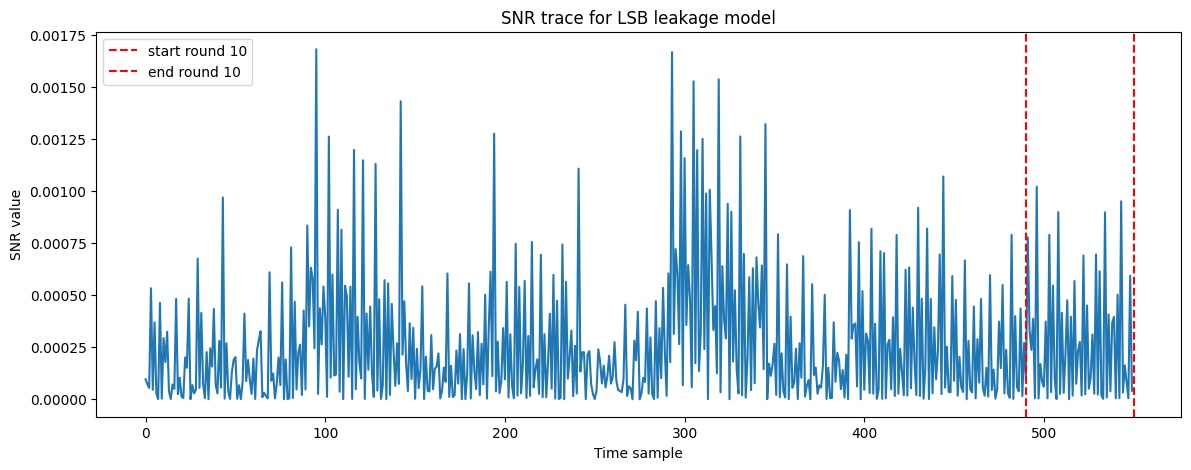

In [19]:
plt.figure(figsize=(14,5))
plt.plot(snr_trace_LSB[50:600])
plt.title("SNR trace for LSB leakage model")
plt.xlabel('Time sample')
plt.ylabel('SNR value')
plt.savefig("SNR_LSB.png")
plt.axvline(x=490, color='red', linestyle='--', label='start round 10')
plt.axvline(x=550, color='red', linestyle='--', label='end round 10')
plt.legend()
#plt.show()

In [ ]:
label_LS2B=[] #the label to divide the data
for i in tqdm(range(0, n_trc), desc='Preparing LS2B labels'):
    label_LS2B.append(round9_byte[i]&0b11)
snr_trace_LS2B=return_snr_trace(trace, label_LS2B)

  0%|          | 0/5000 [00:00<?, ?it/s]

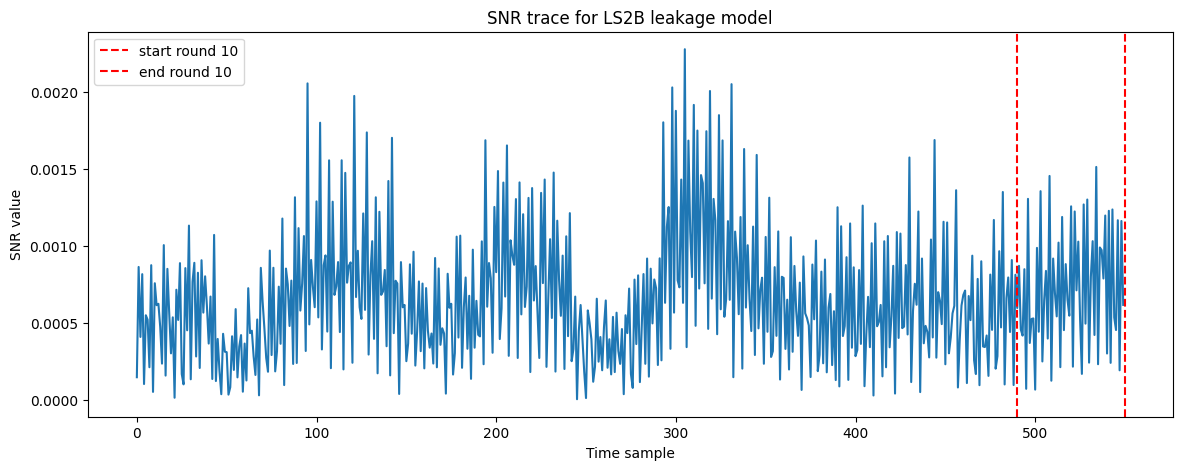

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(snr_trace_LS2B[50:600])
plt.title("SNR trace for LS2B leakage model")
plt.xlabel('Time sample')
plt.ylabel('SNR value')
plt.savefig("graphs/SNR_LS2B.png")
plt.axvline(x=490, color='red', linestyle='--', label='start round 10')
plt.axvline(x=550, color='red', linestyle='--', label='end round 10')
plt.legend()
#plt.show()

In [ ]:
label_MSB=[] #the label to divide the data
for i in tqdm(range(0, n_trc), desc='Preparing MSB labels'):
    label_MSB.append(round9_byte[i]&0b10000000)

snr_trace_MSB=return_snr_trace(trace, label_MSB)

  0%|          | 0/5000 [00:00<?, ?it/s]

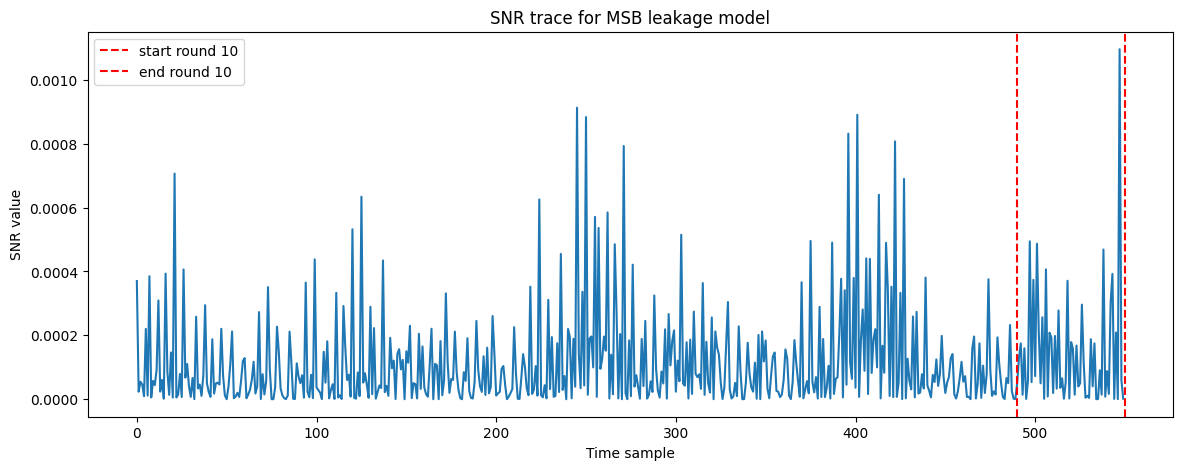

In [25]:
plt.figure(figsize=(14,5))
plt.plot(snr_trace_MSB[50:600])
plt.title("SNR trace for MSB leakage model")
plt.xlabel('Time sample')
plt.ylabel('SNR value')
plt.axvline(x=490, color='red', linestyle='--', label='start round 10')
plt.axvline(x=550, color='red', linestyle='--', label='end round 10')
plt.legend()
plt.show()

In [ ]:
def HW(x):
    return sum([x&(1<<i)>0 for i in range(32)])

def hamming_distance(a,b):
    return HW(a^b)

label_HD=[] #the label to divide the data
for i in tqdm(range(0, n_trc), desc='Preparing HD labels'):
    label_HD.append(hamming_distance(round9_byte[i], ciphertext[i, TARGET_BYTE]))
snr_trace_HD=return_snr_trace(trace, label_HD)

  0%|          | 0/5000 [00:00<?, ?it/s]

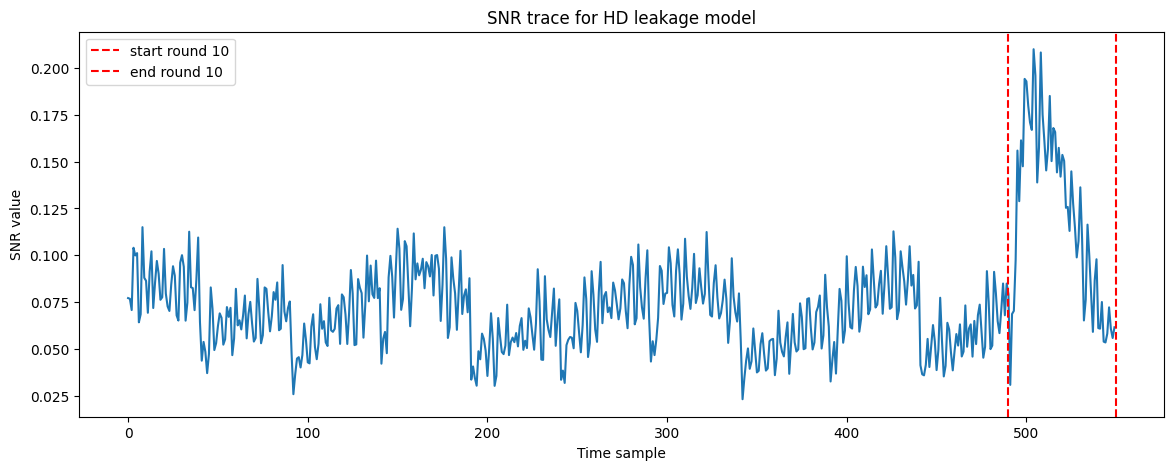

In [27]:
plt.figure(figsize=(14,5))
plt.plot(snr_trace_HD[50:600])
plt.title("SNR trace for HD leakage model")
plt.xlabel('Time sample')
plt.ylabel('SNR value')
plt.axvline(x=490, color='red', linestyle='--', label='start round 10')
plt.axvline(x=550, color='red', linestyle='--', label='end round 10')
plt.legend()
plt.show()

In [28]:
label_ID=[] #the label to divide the data
for i in tqdm(range(0, n_trc), desc='Preparing ID labels'):
    label_ID.append(round9_byte[i])
snr_trace_ID=return_snr_trace(trace, label_ID)

Preparing ID labels:   0%|          | 0/5000 [00:00<?, ?it/s]

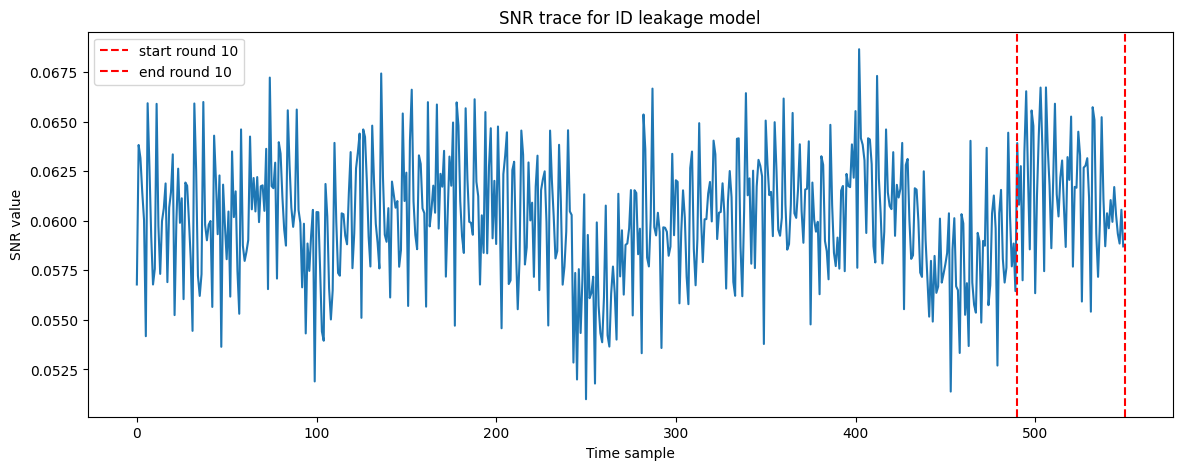

In [29]:

plt.figure(figsize=(14,5))
plt.plot(snr_trace_ID[50:600])
plt.title("SNR trace for ID leakage model")
plt.xlabel('Time sample')
plt.ylabel('SNR value')
plt.axvline(x=490, color='red', linestyle='--', label='start round 10')
plt.axvline(x=550, color='red', linestyle='--', label='end round 10')
plt.legend()
plt.show()

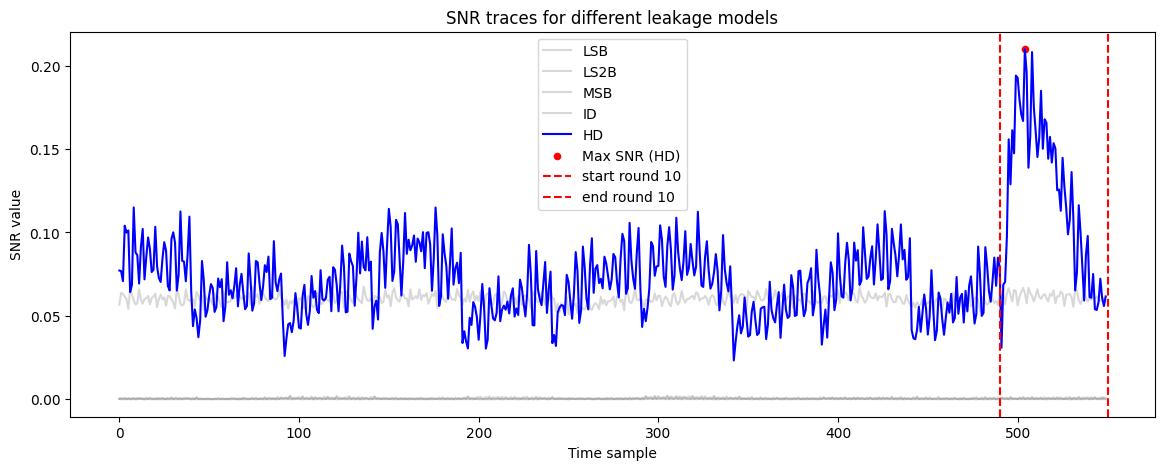

In [30]:
plt.figure(figsize=(14,5))

# Plot all traces in gray with low alpha
plt.plot(snr_trace_LSB[50:600], color='gray', alpha=0.3, label='LSB')
plt.plot(snr_trace_LS2B[50:600], color='gray', alpha=0.3, label='LS2B')
plt.plot(snr_trace_MSB[50:600], color='gray', alpha=0.3, label='MSB')
plt.plot(snr_trace_ID[50:600], color='gray', alpha=0.3, label='ID')

# Plot HD trace in blue, more visible
plt.plot(snr_trace_HD[50:600], color='blue', alpha=1.0, label='HD')

# Find the index and value of the max SNR in HD trace (in the plotted window)
window = slice(50, 600)
snr_hd_window = snr_trace_HD[window]
max_idx = np.argmax(snr_hd_window)
max_val = snr_hd_window[max_idx]

# Plot a circle at the max point
plt.scatter([max_idx], [max_val], color='red', s=20, marker='o', label='Max SNR (HD)')

plt.title("SNR traces for different leakage models")
plt.xlabel('Time sample')
plt.ylabel('SNR value')
plt.axvline(x=490, color='red', linestyle='--', label='start round 10')
plt.axvline(x=550, color='red', linestyle='--', label='end round 10')
plt.legend()
plt.show()